In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/final/final_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

In [3]:
df = df.drop(columns=[
    "Arrival_Unit",
    "Price_Unit",
    "Rain_mm",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_7",
    "Rolling_30",
    "Price_Change"
])

In [4]:
label_encoders = {}

categorical = [
    "State",
    "Commodity_Group",
    "Commodity",
    "District",
    "Festival"
]

for col in categorical:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [5]:
df["Weekend"] = df["Weekend"].astype(int)

df = df.drop(columns=["Date"])

In [6]:
X = df.drop(columns=["Modal_Price"])

y = df["Modal_Price"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [9]:
pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

print("R2 :", r2_score(y_test, pred))

MAE : 13.807488116488928
RMSE : 42.86796311121662
R2 : 0.9989945268448902


In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
1   Commodity_Group    0.498569
11            Month    0.132524
2         Commodity    0.113843
12             Year    0.103638
3           Arrival    0.087338
13              Day    0.027336
16          Quarter    0.015107
15        DayOfWeek    0.005729
5          Max_Temp    0.005098
6          Min_Temp    0.003922
9          Festival    0.003416
7       Rainfall_mm    0.001278
8         WindSpeed    0.001094
10          Holiday    0.000690
14          Weekend    0.000344
4          District    0.000073
0             State    0.000000


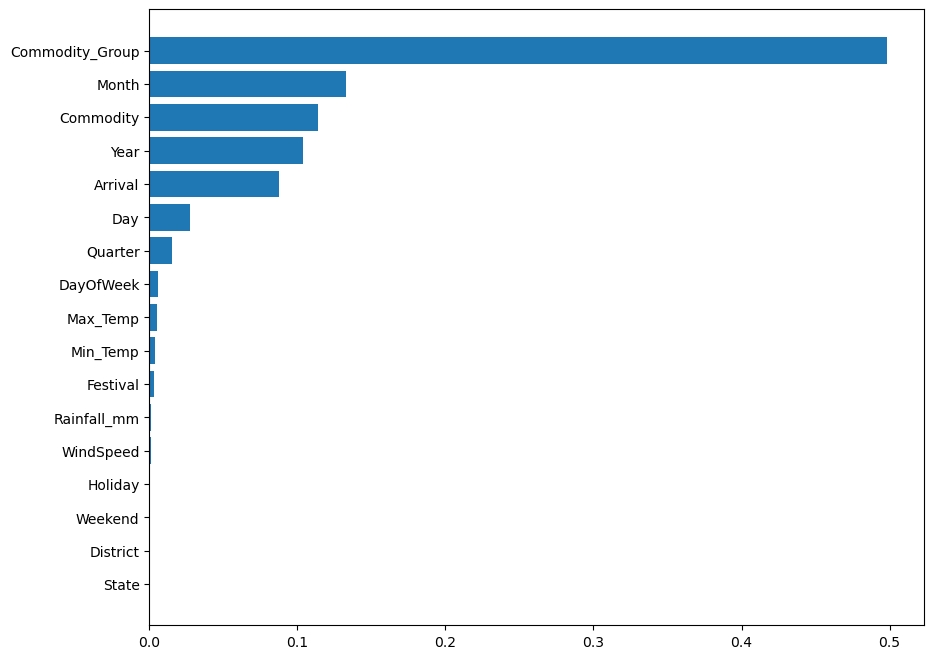

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.show()

In [12]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.4.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.0-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [13]:
from xgboost import XGBRegressor

In [14]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
pred_xgb = xgb_model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2 = r2_score(y_test, pred_xgb)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 94.81281282539352
RMSE: 143.72475531192308
R2 : 0.9886976711519618


In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
1   Commodity_Group    0.675755
2         Commodity    0.079918
16          Quarter    0.063326
12             Year    0.059311
11            Month    0.044013
3           Arrival    0.026327
14          Weekend    0.014322
9          Festival    0.006921
6          Min_Temp    0.005818
15        DayOfWeek    0.005477
13              Day    0.005057
8         WindSpeed    0.004104
10          Holiday    0.003484
5          Max_Temp    0.003171
7       Rainfall_mm    0.002804
4          District    0.000194
0             State    0.000000


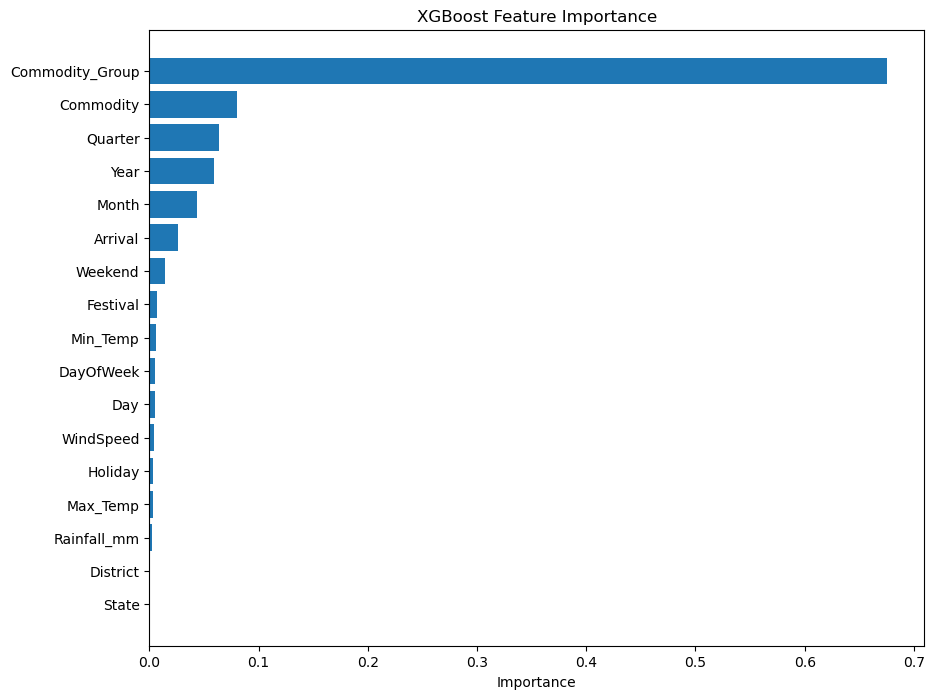

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.show()

In [19]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_weather.pkl"
)

print("XGBoost Model Saved")

XGBoost Model Saved
